Epoch 01 | train_loss=1.8390 train_acc=0.4856 | dev_loss=1.1612 dev_acc=0.6720
Epoch 02 | train_loss=0.9930 train_acc=0.7115 | dev_loss=0.8172 dev_acc=0.7656
Epoch 03 | train_loss=0.7579 train_acc=0.7752 | dev_loss=0.6651 dev_acc=0.8048
Epoch 04 | train_loss=0.6191 train_acc=0.8140 | dev_loss=0.5745 dev_acc=0.8289
Epoch 05 | train_loss=0.5179 train_acc=0.8461 | dev_loss=0.5072 dev_acc=0.8505
Epoch 06 | train_loss=0.4415 train_acc=0.8691 | dev_loss=0.4566 dev_acc=0.8661
Epoch 07 | train_loss=0.3736 train_acc=0.8912 | dev_loss=0.4146 dev_acc=0.8795
Epoch 08 | train_loss=0.3229 train_acc=0.9060 | dev_loss=0.3932 dev_acc=0.8879
Epoch 09 | train_loss=0.2746 train_acc=0.9199 | dev_loss=0.3696 dev_acc=0.8949
Epoch 10 | train_loss=0.2380 train_acc=0.9323 | dev_loss=0.3534 dev_acc=0.9004
Epoch 11 | train_loss=0.2057 train_acc=0.9415 | dev_loss=0.3390 dev_acc=0.9061
Epoch 12 | train_loss=0.1743 train_acc=0.9510 | dev_loss=0.3288 dev_acc=0.9097
Epoch 13 | train_loss=0.1509 train_acc=0.9578 | dev_

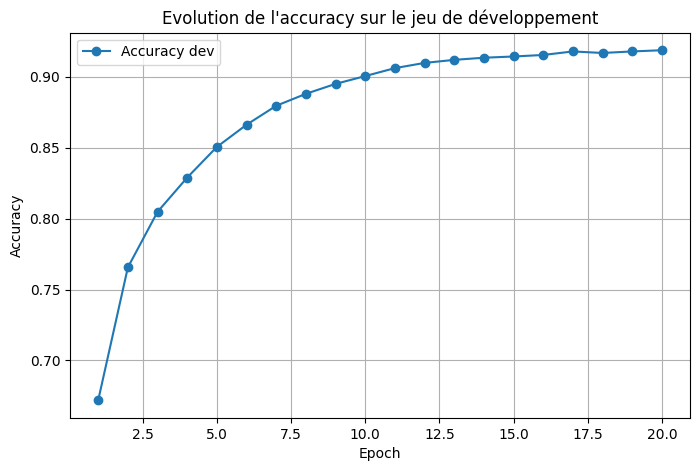

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from lib.conllulib import CoNLLUReader, Util  # :contentReference[oaicite:2]{index=2}

class POSTagger(nn.Module):
    def __init__(self, vocab_size, tagset_size, emb_dim, hid_dim, pad_word_id, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_word_id)
        self.gru = nn.GRU(emb_dim, hid_dim, batch_first=True, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hid_dim, tagset_size)

    def forward(self, x):
        emb = self.embedding(x)          
        out, _ = self.gru(emb)           
        out = self.dropout(out)
        logits = self.fc(out)           
        return logits



def pad_sequences(seqs, max_len, pad_id):
    out = torch.full((len(seqs), max_len), pad_id, dtype=torch.long)
    for i, s in enumerate(seqs):
        if torch.is_tensor(s):
            s = s.tolist()
        s = s[:max_len]
        out[i, :len(s)] = torch.tensor(s, dtype=torch.long)
    return out


@torch.no_grad()
def perf(model, loader, criterion, pad_tag_id, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)  
        loss = criterion(logits.transpose(1, 2), y) 
        total_loss += loss.item()

        preds = logits.argmax(dim=-1) 
        mask = (y != pad_tag_id)
        correct += (preds[mask] == y[mask]).sum().item()
        total += mask.sum().item()

    avg_loss = total_loss / len(loader)
    acc = correct / total if total > 0 else 0.0
    return avg_loss, acc


import json
import torch

def fit(model, train_loader, dev_loader, optimizer, criterion,
        pad_tag_id, device, epochs,
      ):

    hist = {"train_acc": [], "dev_acc": [], "train_loss": [], "dev_loss": []}

    for epoch in range(1, epochs + 1):
        model.train()
        sum_loss = 0.0
        correct = 0
        total = 0
        nb_batches = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(x) 

            loss = criterion(logits.transpose(1, 2), y)
            loss.backward()
            optimizer.step()

            sum_loss += loss.item()
            nb_batches += 1

            preds = logits.argmax(dim=-1)  
            mask = (y != pad_tag_id)
            correct += (preds[mask] == y[mask]).sum().item()
            total += mask.sum().item()

        train_loss = sum_loss / max(nb_batches, 1)
        train_acc = correct / total if total > 0 else 0.0

        dev_loss, dev_acc = perf(model, dev_loader, criterion, pad_tag_id, device)

        hist["train_loss"].append(train_loss)
        hist["train_acc"].append(train_acc)
        hist["dev_loss"].append(dev_loss)
        hist["dev_acc"].append(dev_acc)

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"dev_loss={dev_loss:.4f} dev_acc={dev_acc:.4f}"
        )

    torch.save({
    "model_state": model.state_dict(),
    "Vw": dict(Vw),
    "Vt": dict(Vt),
    "PAD_WORD_ID": PAD_WORD_ID,
    "PAD_TAG_ID": PAD_TAG_ID,
    "UNK_ID": UNK_ID,
    "MAX_LEN": MAX_LEN,
    "EMB_DIM": EMB_DIM,
    "HID_DIM": HID_DIM,
}, "resultats/postagger.pt")
    

   

    with open("resultats/hist_postagger.json", "w", encoding="utf-8") as f:
        json.dump(hist, f, ensure_ascii=False, indent=2)

    return hist

TRAIN_FILE = "sequoia/sequoia-ud.parseme.frsemcor.simple.train"
DEV_FILE   = "sequoia/sequoia-ud.parseme.frsemcor.simple.dev"

MAX_LEN = 50
BATCH_SIZE = 32
EPOCHS = 10
EMB_DIM = 100
HID_DIM = 128
LR = 1e-3

with open(TRAIN_FILE, encoding="utf-8") as f:
    reader = CoNLLUReader(f)
    train_int, vocab = reader.to_int_and_vocab({
        "form": ["<PAD>", "<UNK>"],
        "upos": ["<PAD>"]
    })

Vw = vocab["form"]
Vt = vocab["upos"]

PAD_WORD_ID = Vw["<PAD>"]
UNK_ID = Vw["<UNK>"]
PAD_TAG_ID  = Vt["<PAD>"]

X_train_list = train_int["form"]
y_train_list = train_int["upos"]

with open(DEV_FILE, encoding="utf-8") as f:
    reader = CoNLLUReader(f)
    dev_int = reader.to_int_from_vocab(
        col_names=["form", "upos"],
        unk_token="<UNK>",
        vocab=vocab
    )

X_dev_list = dev_int["form"]
y_dev_list = dev_int["upos"]

X_train = pad_sequences(X_train_list, MAX_LEN, PAD_WORD_ID)
y_train = pad_sequences(y_train_list, MAX_LEN, PAD_TAG_ID)

X_dev = pad_sequences(X_dev_list, MAX_LEN, PAD_WORD_ID)
y_dev = pad_sequences(y_dev_list, MAX_LEN, PAD_TAG_ID)

train_loader = Util.dataloader([X_train], [y_train], batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = Util.dataloader([X_dev],   [y_dev],   batch_size=BATCH_SIZE, shuffle=False)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = POSTagger(
    vocab_size=len(Vw),
    tagset_size=len(Vt),
    emb_dim=EMB_DIM,
    hid_dim=HID_DIM,
    pad_word_id=PAD_WORD_ID
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_TAG_ID)
optimizer = optim.Adam(model.parameters(), lr=LR)

hist=fit(
    model=model,
    train_loader=train_loader,       
    dev_loader=dev_loader,       
    optimizer=optimizer,
    criterion=criterion,
    pad_tag_id=PAD_TAG_ID,
    device=device,
    epochs=20,
)
import matplotlib.pyplot as plt

epochs = range(1, len(hist["dev_acc"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, hist["dev_acc"], label="Accuracy dev", marker="o")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolution de l'accuracy sur le jeu de développement")
plt.legend()
plt.grid(True)

plt.show()

